# NVIDIA DCF Valuation Model
---
### Model Structure
- Revenue forecast with Constant Growth or Growth Convergence
- EBIT = Revenue x margin, Taxes compound from last actual
- UFCF = EBIAT + D&A + CapEx + Change in NWC
- Terminal Value via Gordon Growth Model
- Equity Value = EV + Cash - Debt

In [1]:
import requests
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns', 20)

TICKER = "NVDA"
CIK = "0001045810"  # NVIDIA SEC CIK (10-digit, zero-padded)
HEADERS = {"User-Agent": "DCFModel/1.0 research@example.com"}

# ── Configure historical range ──
LAST_HIST_FY = 25   # Last historical fiscal year (FY25 = ends Jan 2025)
HIST_YEARS = 11     # Number of historical years (FY15-FY25 = 11)

## SEC EDGAR Data Fetcher
The XBRL companyfacts API returns (almost) every financial concept from all 10-K filings.

In [3]:
def fetch_edgar_facts(cik, headers):
    url = f"https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json"
    resp = requests.get(url, headers=headers, timeout=30)
    resp.raise_for_status()
    return resp.json()

def extract_annual_concept(facts_json, tag, unit="USD", form="10-K", min_days=300, max_days=450):
    """
    Extract annual values for a US-GAAP tag from EDGAR companyfacts JSON.
    
    Key improvements:
    - Filters by DURATION (300-450 days) to exclude quarterly data inside 10-K filings
    - For balance sheet (instant) items, accepts entries without start date
    - Deduplicates by end date, keeping the latest filing
    """
    try:
        entries = facts_json["facts"]["us-gaap"][tag]["units"][unit]
    except KeyError:
        return {}
    
    by_end = {}
    for e in entries:
        if e.get("form") != form:
            continue
        end = e.get("end", "")
        start = e.get("start", "")
        filed = e.get("filed", "")
        
        # Duration filter: only keep annual-length periods
        if start and end:
            from datetime import datetime
            try:
                d_start = datetime.strptime(start, "%Y-%m-%d")
                d_end = datetime.strptime(end, "%Y-%m-%d")
                days = (d_end - d_start).days
                if days < min_days or days > max_days:
                    continue  # Skip quarterly or multi-year entries
            except ValueError:
                pass
        # If no start date, it is an instant/balance-sheet item -> keep it
        
        if end not in by_end or filed > by_end[end].get("filed", ""):
            by_end[end] = e
    
    return {k: v["val"] for k, v in sorted(by_end.items())}

def extract_annual_shares(facts_json, tag, form="10-K"):
    return extract_annual_concept(facts_json, tag, unit="shares", form=form)

def get_fy_label(end_date_str):
    year = int(end_date_str.split("-")[0])
    month = int(end_date_str.split("-")[1])
    if month <= 2:
        return f"FY{str(year)[2:]}"
    return f"FY{str(year + 1)[2:]}"

def try_tags(facts, tags, unit="USD", form="10-K"):
    """Merge data across multiple XBRL tags to maximize year coverage.
    Older filings use different tag names (e.g. Revenues vs
    RevenueFromContractWithCustomerExcludingAssessedTax).
    Earlier tags in the list are treated as fallback; later tags override."""
    merged = {}
    used_tags = []
    for tag in tags:
        data = extract_annual_concept(facts, tag, unit=unit, form=form)
        if data:
            used_tags.append(f"{tag}({len(data)})")
            for k, v in data.items():
                if k not in merged:  # Earlier tags fill gaps; later ones don't override
                    merged[k] = v
    return dict(sorted(merged.items())), used_tags

def try_share_tags(facts, tags, form="10-K"):
    merged = {}
    used_tags = []
    for tag in tags:
        data = extract_annual_shares(facts, tag, form=form)
        if data:
            used_tags.append(f"{tag}({len(data)})")
            for k, v in data.items():
                if k not in merged:
                    merged[k] = v
    return dict(sorted(merged.items())), used_tags

print("EDGAR helper functions defined (with duration filter).")

EDGAR helper functions defined (with duration filter).


## Fetch & Extract Data

In [4]:
USE_EDGAR = False
SCALE = 1e6

TAG_MAP = {
    # Income Statement
    "revenue": ["SalesRevenueNet", "Revenues",
                 "RevenueFromContractWithCustomerExcludingAssessedTax"],
    "ebit": ["OperatingIncomeLoss"],
    "pretax": ["IncomeLossFromContinuingOperationsBeforeIncomeTaxesMinorityInterestAndIncomeLossFromEquityMethodInvestments",
               "IncomeLossFromContinuingOperationsBeforeIncomeTaxesExtraordinaryItemsNoncontrollingInterest"],
    "tax": ["IncomeTaxExpenseBenefit"],

    # Cash Flow
    "da": ["DepreciationAndAmortization", "DepreciationDepletionAndAmortization"],
    "capex_direct": ["PaymentsToAcquirePropertyPlantAndEquipment",
                     "PaymentsToAcquireProductiveAssets"],
    "ppenet": ["PropertyPlantAndEquipmentNet"],

    # Balance Sheet: NWC components
    # Excel NWC = SUM(changes in AR, Inv, Prepaid, AP, Accrued, Other LT Liab)
    # We compute from balance sheet deltas to match
    "ar": ["AccountsReceivableNetCurrent"],
    "inv": ["InventoryNet"],
    "prepaid": ["PrepaidExpenseAndOtherAssetsCurrent"],
    "ap": ["AccountsPayableCurrent"],
    "accrued": ["AccruedLiabilitiesCurrent"],
    "other_lt_liab": ["OtherLiabilitiesNoncurrent"],

    # Equity bridge
    "cash": ["CashAndCashEquivalentsAtCarryingValue",
             "CashCashEquivalentsAndShortTermInvestments"],
    "lt_debt": ["LongTermDebtNoncurrent", "LongTermDebt"],
    "st_debt": ["DebtCurrent", "LongTermDebtCurrent", "ShortTermBorrowings"],
    "interest": ["InterestExpense", "InterestExpenseDebt",
                 "InterestExpenseNonoperating"],
    "shares": ["WeightedAverageNumberOfDilutedSharesOutstanding",
               "CommonStockSharesOutstanding"],
}

try:
    print(f"Fetching EDGAR data for CIK {CIK}...")
    facts = fetch_edgar_facts(CIK, HEADERS)
    print(f"Company: {facts.get('entityName', TICKER)}\n")

    extracted = {}
    for key, tags in TAG_MAP.items():
        if key == "shares":
            data, used = try_share_tags(facts, tags)
        else:
            data, used = try_tags(facts, tags)
        extracted[key] = data
        fy_labels = [get_fy_label(d) for d in data.keys()]
        if used:
            print(f"  {key:14s} -> {', '.join(used)}")
            print(f"                 FYs: {fy_labels}")
        else:
            print(f"  {key:14s} -> NOT FOUND")

    def to_fy(data, scale=SCALE):
        if not data:
            return pd.Series(dtype=float)
        return pd.Series({get_fy_label(k): v/scale for k, v in data.items()}).sort_index()

    rev_raw = to_fy(extracted["revenue"])
    ebit_raw = to_fy(extracted["ebit"])
    pretax_raw = to_fy(extracted["pretax"])
    tax_raw = to_fy(extracted["tax"])
    da_raw = to_fy(extracted["da"])
    capex_direct_raw = to_fy(extracted["capex_direct"])
    ppenet_raw = to_fy(extracted["ppenet"])
    cash_raw = to_fy(extracted["cash"])
    lt_debt_raw = to_fy(extracted["lt_debt"])
    st_debt_raw = to_fy(extracted["st_debt"])
    interest_raw = to_fy(extracted["interest"])
    shares_raw = to_fy(extracted["shares"], scale=SCALE)

    # Balance sheet NWC components
    ar_raw = to_fy(extracted["ar"])
    inv_raw = to_fy(extracted["inv"])
    pre_raw = to_fy(extracted["prepaid"])
    ap_raw = to_fy(extracted["ap"])
    acc_raw = to_fy(extracted["accrued"])
    olt_raw = to_fy(extracted["other_lt_liab"])

    # Target FYs
    # Filter to historical range: FY(LAST_HIST_FY - HIST_YEARS + 1) to FY(LAST_HIST_FY)
    all_fys = sorted(rev_raw.index)
    first_fy = LAST_HIST_FY - HIST_YEARS + 1  # e.g. 15
    target_fys = [fy for fy in all_fys if first_fy <= int(fy.replace('FY','')) <= LAST_HIST_FY]
    # Extended: 1 extra year before for NWC delta
    extended_fys = [fy for fy in all_fys if (first_fy - 1) <= int(fy.replace('FY','')) <= LAST_HIST_FY]

    def align(s, fys=None):
        return s.reindex(fys or target_fys).fillna(0)

    revenue = align(rev_raw)
    ebit = align(ebit_raw)
    income_before_tax = align(pretax_raw)
    tax_expense = align(tax_raw)
    depreciation = align(da_raw)

    # ═══════════════════════════════════════════════
    # CapEx: direct tags + PP&E identity for gaps
    # NOTE: PP&E identity overestimates CapEx because it includes
    # non-cash items (acquisitions, disposals, write-downs).
    # We prefer direct tags where available.
    # ═══════════════════════════════════════════════
    ppenet_s = ppenet_raw.sort_index()
    da_s = da_raw.sort_index()
    capex_computed = pd.Series(dtype=float)
    common_pp = sorted(set(ppenet_s.index) & set(da_s.index))
    for j in range(1, len(common_pp)):
        fy, fy_prev = common_pp[j], common_pp[j-1]
        capex_computed[fy] = ppenet_s[fy] - ppenet_s[fy_prev] + da_s[fy]

    capex_merged = capex_direct_raw.copy()
    filled_capex = []
    for fy in target_fys:
        if fy not in capex_merged.index or capex_merged.get(fy, 0) == 0:
            if fy in capex_computed.index:
                capex_merged[fy] = capex_computed[fy]
                filled_capex.append(fy)
    capex_merged = capex_merged.sort_index()
    capex = -abs(align(capex_merged))

    print(f"\n  CapEx: direct tags for {sorted(set(capex_direct_raw.index) & set(target_fys))}")
    if filled_capex:
        print(f"  CapEx: PP&E identity for {filled_capex}")
        print(f"  NOTE: PP&E identity overestimates CapEx (includes non-cash items)")

    # Validation
    both = sorted(set(capex_direct_raw.index) & set(capex_computed.index) & set(target_fys))
    if both:
        print(f"\n  CapEx Validation (Direct vs PP&E Identity):")
        for fy in both:
            d = capex_direct_raw.get(fy, 0)
            c = capex_computed.get(fy, 0)
            print(f"    {fy}: Direct={d:>8,.0f}  Computed={c:>8,.0f}  Ratio={d/c:.0%}")

    # ═══════════════════════════════════════════════
    # NWC: Balance Sheet delta approach
    # Matches Excel: SUM(AR + Inv + Prepaid - AP - Accrued - OtherLTLiab)
    # Change in NWC = -(NWC_t - NWC_{t-1})  [negative = cash used]
    # ═══════════════════════════════════════════════
    nwc_level_ext = (align(ar_raw, extended_fys)
                     + align(inv_raw, extended_fys)
                     + align(pre_raw, extended_fys)
                     - align(ap_raw, extended_fys)
                     - align(acc_raw, extended_fys)
                     - align(olt_raw, extended_fys))

    change_nwc_ext = -nwc_level_ext.diff()
    # Take only the target_fys (dropping the extra leading year)
    change_nwc = change_nwc_ext.reindex(target_fys).fillna(0)

    print(f"\n  NWC method: Balance Sheet Delta (AR+Inv+Prepaid-AP-Accrued-OtherLT)")
    print(f"  NWC values:")
    for fy in target_fys:
        print(f"    {fy}: {change_nwc[fy]:>10,.0f}")

    # Other items
    cash_s = cash_raw.iloc[[-1]]
    debt_combined = lt_debt_raw.add(st_debt_raw.reindex(lt_debt_raw.index, fill_value=0), fill_value=0)
    total_debt_s = debt_combined.iloc[[-1]] if len(debt_combined) > 0 else pd.Series([0])
    diluted_shares_s = align(shares_raw)
    interest_exp_val = interest_raw.iloc[-1] if len(interest_raw) > 0 else 250
    print(f"\n  Interest: ${interest_exp_val:,.0f}M ({interest_raw.index[-1]})")

    USE_EDGAR = True
    print(f"\n{'='*60}")
    print(f"  SEC EDGAR: {len(target_fys)} fiscal years loaded")
    print(f"  {target_fys[0]} to {target_fys[-1]}")
    print(f"  Revenue: ${revenue.iloc[0]:,.0f}M -> ${revenue.iloc[-1]:,.0f}M")
    print(f"{'='*60}")

except Exception as e:
    import traceback
    print(f"EDGAR failed: {type(e).__name__}: {e}")
    traceback.print_exc()
    print("Will use fallback data.")

Fetching EDGAR data for CIK 0001045810...
Company: NVIDIA CORP

  revenue        -> Revenues(18), RevenueFromContractWithCustomerExcludingAssessedTax(6)
                 FYs: ['FY08', 'FY09', 'FY10', 'FY11', 'FY12', 'FY13', 'FY14', 'FY15', 'FY16', 'FY17', 'FY18', 'FY19', 'FY20', 'FY21', 'FY22', 'FY23', 'FY24', 'FY25', 'FY26']
  ebit           -> OperatingIncomeLoss(19)
                 FYs: ['FY08', 'FY09', 'FY10', 'FY11', 'FY12', 'FY13', 'FY14', 'FY15', 'FY16', 'FY17', 'FY18', 'FY19', 'FY20', 'FY21', 'FY22', 'FY23', 'FY24', 'FY25', 'FY26']
  pretax         -> IncomeLossFromContinuingOperationsBeforeIncomeTaxesMinorityInterestAndIncomeLossFromEquityMethodInvestments(13), IncomeLossFromContinuingOperationsBeforeIncomeTaxesExtraordinaryItemsNoncontrollingInterest(7)
                 FYs: ['FY09', 'FY10', 'FY11', 'FY12', 'FY13', 'FY14', 'FY15', 'FY16', 'FY17', 'FY18', 'FY19', 'FY20', 'FY21', 'FY22', 'FY23', 'FY24', 'FY25', 'FY26']
  tax            -> IncomeTaxExpenseBenefit(19)
          

In [5]:
# Fallback (static data for verification and if EDGAR unavailable)
if not USE_EDGAR:
    fy = ['FY15','FY16','FY17','FY18','FY19','FY20','FY21','FY22','FY23','FY24','FY25']
    revenue = pd.Series([4682,5010,6910,9714,11716,10918,16675,26914,26974,60922,130497], index=fy, dtype=float)
    ebit = pd.Series([759,747,1934,3210,3804,2846,4532,10041,4224,32972,81453], index=fy, dtype=float)
    tax_expense = pd.Series([124,129,239,149,-245,174,77,189,-187,4058,11146], index=fy, dtype=float)
    income_before_tax = pd.Series([755,743,1905,3196,3896,2970,4409,9941,4181,33818,84026], index=fy, dtype=float)
    depreciation = pd.Series([220,197,187,199,262,381,1098,1174,1544,1508,1864], index=fy, dtype=float)
    capex = pd.Series([-122,-86,-176,-593,-600,-489,-1128,-976,-1833,-1069,-3236], index=fy, dtype=float)
    change_nwc = pd.Series([-203,-51,-679,185,-857,717,-703,-3363,-2207,-3722,-9383], index=fy, dtype=float)
    cash_s = pd.Series([8589.0], index=['FY25'])
    total_debt_s = pd.Series([8463.0], index=['FY25'])
    diluted_shares_s = pd.Series([569,569,649,632,625,2472,2510,2535,25070,24940,24804], index=fy, dtype=float)
    interest_exp_val = 247.0
    print("Fallback data loaded (FY15-FY25)")

# Market data
try:
    import yfinance as yf
    info = yf.Ticker(TICKER).info
    current_price = info.get('currentPrice', info.get('regularMarketPrice', 130))
    shares_out_M = info.get('sharesOutstanding', 24500000000) / 1e6
    beta_val = info.get('beta', 1.7)
    print(f"Market data via yfinance: ${current_price:.2f}, beta={beta_val:.2f}")
except Exception:
    current_price = 130.0   # UPDATE with current NVDA price
    shares_out_M = 24400.0  # UPDATE with shares outstanding (M)
    beta_val = 1.65         # UPDATE with current beta
    print(f"Manual market data: ${current_price}, beta={beta_val}")
    print("TIP: pip install yfinance for live market data")

Market data via yfinance: $180.05, beta=2.38


## Historical Ratios

In [6]:
print("--- Historical Data ($M) ---")
display(pd.DataFrame({
    'Revenue': revenue, 'EBIT': ebit, 'Tax': tax_expense,
    'D&A': depreciation, 'CapEx': capex, 'Chg NWC': change_nwc,
}).T.style.format('${:,.0f}'))

rv = revenue.values
rev_growth = pd.Series(
    [np.nan] + [(rv[i]-rv[i-1])/rv[i-1] for i in range(1, len(rv))],
    index=revenue.index)
ebit_margin   = ebit / revenue
eff_tax_rate  = tax_expense / income_before_tax
da_pct_rev    = depreciation / revenue
capex_pct_rev = capex / revenue
nwc_pct_rev   = change_nwc / revenue

print("\n--- Historical Ratios ---")
display(pd.DataFrame({
    'Rev Growth': rev_growth, 'EBIT Margin': ebit_margin,
    'Eff Tax Rate': eff_tax_rate, 'D&A %': da_pct_rev,
    'CapEx %': capex_pct_rev, 'NWC %': nwc_pct_rev
}).T.style.format('{:.2%}', na_rep='--'))

--- Historical Data ($M) ---


,FY15,FY16,FY17,FY18,FY19,FY20,FY21,FY22,FY23,FY24,FY25
Revenue,"$4,682","$5,010","$6,910","$9,714","$11,716","$10,918","$16,675","$26,914","$26,974","$60,922","$130,497"
EBIT,$759,$747,"$1,934","$3,210","$3,804","$2,846","$4,532","$10,041","$4,224","$32,972","$81,453"
Tax,$124,$129,$239,$149,$-245,$174,$77,$189,$-187,"$4,058","$11,146"
D&A,$220,$197,$187,$199,$262,$381,"$1,098","$1,174","$1,544","$1,508","$1,864"
CapEx,$-194,$-106,$-242,$-675,$-669,$-651,"$-1,573",$-976,"$-1,833","$-1,069","$-3,236"
Chg NWC,$-178,$17,$-844,$92,$-796,$939,$41,"$-1,540",$-818,"$-3,888","$-8,185"



--- Historical Ratios ---


,FY15,FY16,FY17,FY18,FY19,FY20,FY21,FY22,FY23,FY24,FY25
Rev Growth,--,7.01%,37.92%,40.58%,20.61%,-6.81%,52.73%,61.40%,0.22%,125.85%,114.20%
EBIT Margin,16.21%,14.91%,27.99%,33.05%,32.47%,26.07%,27.18%,37.31%,15.66%,54.12%,62.42%
Eff Tax Rate,16.42%,17.36%,12.55%,4.66%,-6.29%,5.86%,1.75%,1.90%,-4.47%,12.00%,13.26%
D&A %,4.70%,3.93%,2.71%,2.05%,2.24%,3.49%,6.58%,4.36%,5.72%,2.48%,1.43%
CapEx %,-4.15%,-2.12%,-3.50%,-6.95%,-5.71%,-5.96%,-9.43%,-3.63%,-6.80%,-1.75%,-2.48%
NWC %,-3.81%,0.34%,-12.21%,0.95%,-6.79%,8.60%,0.25%,-5.72%,-3.03%,-6.38%,-6.27%


## WACC (CAPM)

In [7]:
market_cap = current_price * shares_out_M
beta = beta_val
debt_total = total_debt_s.iloc[-1]
latest_cash = cash_s.iloc[-1]

risk_free_rate = 0.0413; market_return = 0.07; wacc_tax_rate = 0.17
mrp = market_return - risk_free_rate
cost_of_equity = risk_free_rate + beta * mrp
cost_of_debt = interest_exp_val / debt_total if debt_total > 0 else 0.03
eq_w = market_cap / (market_cap + debt_total)
d_w = debt_total / (market_cap + debt_total)
wacc = eq_w * cost_of_equity + d_w * cost_of_debt * (1 - wacc_tax_rate)

print("=" * 52)
print("             WACC CALCULATION")
print("=" * 52)
print(f"  Market Cap:         ${market_cap:>12,.0f}M")
print(f"  Total Debt:         ${debt_total:>12,.0f}M")
print(f"  Equity / Debt:       {eq_w:.4%} / {d_w:.4%}")
print(f"  Risk-Free Rate:      {risk_free_rate:.2%}")
print(f"  Beta:                {beta:.4f}")
print(f"  Cost of Equity:      {cost_of_equity:.2%}")
print(f"  Cost of Debt:        {cost_of_debt:.2%}")
print(f"  WACC:               {wacc:.2%}")
print("=" * 52)

             WACC CALCULATION
  Market Cap:         $   4,375,215M
  Total Debt:         $       8,468M
  Equity / Debt:       99.8068% / 0.1932%
  Risk-Free Rate:      4.13%
  Beta:                2.3750
  Cost of Equity:      10.95%
  Cost of Debt:        3.06%
  WACC:               10.93%


## Forecast Assumptions
| Mode | Logic |
|------|-------|
| **Constant Growth** | All years = target (or hist avg if 0) |
| **Growth Convergence** | Year 5 = anchor; Years 1-4 converge iteratively |

In [8]:
FORECAST_YEARS = 5
assumptions = {
    'revenue_growth': ('Growth Convergence', 0.15),
    'ebit_margin':    ('Constant Growth',    0),
    'tax_rate':       ('Constant Growth',    0.17),
    'da_pct':         ('Growth Convergence', 0),
    'capex_pct':      ('Growth Convergence', 0),
    'nwc_pct':        ('Constant Growth',    0),
}
perpetuity_growth_rate = 0.045

print("--- Assumptions ---")
for k, (m, v) in assumptions.items():
    print(f"  {k:20s} | {m:20s} | {f'{v:.2%}' if v else 'hist.avg'}")
print(f"  perpetuity_g       | {perpetuity_growth_rate:.2%}")
print(f"  WACC               | {wacc:.2%}")

--- Assumptions ---
  revenue_growth       | Growth Convergence   | 15.00%
  ebit_margin          | Constant Growth      | hist.avg
  tax_rate             | Constant Growth      | 17.00%
  da_pct               | Growth Convergence   | hist.avg
  capex_pct            | Growth Convergence   | hist.avg
  nwc_pct              | Constant Growth      | hist.avg
  perpetuity_g       | 4.50%
  WACC               | 10.93%


## Forecast Engine

In [9]:
def forecast_metric(hist_series, mode, target, n=5):
    h = hist_series.dropna()
    base = target if target != 0 else h.mean()
    last = h.iloc[-1]
    if mode == 'Constant Growth':
        return [base] * n
    f = [base] * n
    for _ in range(500):
        fn = f.copy()
        fn[-1] = base
        for i in range(n-2, -1, -1):
            left = last if i == 0 else fn[i-1]
            fn[i] = (left + fn[i+1]) / 2
        if max(abs(fn[j]-f[j]) for j in range(n)) < 1e-14:
            break
        f = fn
    return f

## DCF Projection

In [10]:
last_fy = int(revenue.index[-1].replace('FY', ''))
flabels = [f"FY{last_fy+i+1}E" for i in range(FORECAST_YEARS)]

hist_map = {'revenue_growth': rev_growth, 'ebit_margin': ebit_margin,
    'tax_rate': eff_tax_rate, 'da_pct': da_pct_rev,
    'capex_pct': capex_pct_rev, 'nwc_pct': nwc_pct_rev}

fc = {k: forecast_metric(hist_map[k], m, t, FORECAST_YEARS) for k, (m, t) in assumptions.items()}

f_rev, prev = [], revenue.iloc[-1]
for i in range(FORECAST_YEARS):
    prev *= (1 + fc['revenue_growth'][i]); f_rev.append(prev)

f_ebit = [f_rev[i] * fc['ebit_margin'][i] for i in range(FORECAST_YEARS)]

f_tax, pt = [], tax_expense.iloc[-1]
for i in range(FORECAST_YEARS):
    pt *= (1 + fc['tax_rate'][i]); f_tax.append(pt)

f_ebiat = [f_ebit[i]-f_tax[i] for i in range(FORECAST_YEARS)]
f_da  = [f_rev[i]*fc['da_pct'][i] for i in range(FORECAST_YEARS)]
f_cx  = [f_rev[i]*fc['capex_pct'][i] for i in range(FORECAST_YEARS)]
f_nwc = [f_rev[i]*fc['nwc_pct'][i] for i in range(FORECAST_YEARS)]
f_ufcf = [f_ebiat[i]+f_da[i]+f_cx[i]+f_nwc[i] for i in range(FORECAST_YEARS)]

print("--- Drivers ---")
display(pd.DataFrame({
    'Rev Growth': fc['revenue_growth'], 'EBIT Margin': fc['ebit_margin'],
    'Tax Rate': fc['tax_rate'], 'D&A %': fc['da_pct'],
    'CapEx %': fc['capex_pct'], 'NWC %': fc['nwc_pct'],
}, index=flabels).T.style.format('{:.2%}'))

print("\n--- Projected Cash Flows ($M) ---")
display(pd.DataFrame({
    'Revenue': f_rev, 'EBIT': f_ebit, 'Taxes': f_tax, 'EBIAT': f_ebiat,
    'D&A': f_da, 'CapEx': f_cx, 'NWC': f_nwc, 'UFCF': f_ufcf,
}, index=flabels).T.style.format('${:,.0f}'))

--- Drivers ---


,FY26E,FY27E,FY28E,FY29E,FY30E
Rev Growth,94.36%,74.52%,54.68%,34.84%,15.00%
EBIT Margin,31.58%,31.58%,31.58%,31.58%,31.58%
Tax Rate,17.00%,17.00%,17.00%,17.00%,17.00%
D&A %,1.86%,2.30%,2.74%,3.17%,3.61%
CapEx %,-2.94%,-3.40%,-3.85%,-4.31%,-4.77%
NWC %,-3.10%,-3.10%,-3.10%,-3.10%,-3.10%



--- Projected Cash Flows ($M) ---


,FY26E,FY27E,FY28E,FY29E,FY30E
Revenue,"$253,638","$442,653","$684,702","$923,257","$1,061,746"
EBIT,"$80,098","$139,788","$216,226","$291,560","$335,295"
Taxes,"$13,041","$15,258","$17,852","$20,886","$24,437"
EBIAT,"$67,057","$124,530","$198,374","$270,674","$310,858"
D&A,"$4,729","$10,182","$18,734","$29,285","$38,306"
CapEx,"$-7,452","$-15,033","$-26,391","$-39,816","$-50,653"
NWC,"$-7,861","$-13,718","$-21,220","$-28,613","$-32,905"
UFCF,"$56,473","$105,960","$169,498","$231,531","$265,606"


## DCF Valuation

In [11]:
pv_fcfs = [f_ufcf[i]/(1+wacc)**(i+1) for i in range(FORECAST_YEARS)]
tv = (f_ufcf[-1]*(1+perpetuity_growth_rate))/(wacc-perpetuity_growth_rate)
# Excel discounts TV by (1+WACC)^1. Use **FORECAST_YEARS for standard approach.
pv_tv = tv / (1+wacc)**1

ev = sum(pv_fcfs) + pv_tv
latest_debt = total_debt_s.iloc[-1]
eq_val = ev + latest_cash - latest_debt
dil_shares = diluted_shares_s.iloc[-1]
impl_price = eq_val / dil_shares
upside = (impl_price / current_price) - 1

print("=" * 62)
print("              DCF VALUATION SUMMARY")
print("=" * 62)
print(f"  WACC: {wacc:.2%}    Terminal g: {perpetuity_growth_rate:.2%}")
print(f"  ---")
for i in range(FORECAST_YEARS):
    print(f"  {flabels[i]:6s} UFCF: ${f_ufcf[i]:>14,.0f}M | PV: ${pv_fcfs[i]:>14,.0f}M")
print(f"  ---")
print(f"  Sum PV(FCFs):         ${sum(pv_fcfs):>14,.0f}M")
print(f"  Terminal Value:       ${tv:>14,.0f}M")
print(f"  PV of TV:             ${pv_tv:>14,.0f}M")
print(f"  ---")
print(f"  Enterprise Value:     ${ev:>14,.0f}M")
print(f"  (+) Cash:             ${latest_cash:>14,.0f}M")
print(f"  (-) Debt:            (${latest_debt:>13,.0f}M)")
print(f"  Equity Value:         ${eq_val:>14,.0f}M")
print(f"  ---")
print(f"  Diluted Shares:        {dil_shares:>13,.0f}M")
print(f"  >> Implied Price:     ${impl_price:>14,.2f}")
print(f"  Current Price:        ${current_price:>14,.2f}")
d = 'UPSIDE' if upside >= 0 else 'DOWNSIDE'
print(f"  >> {d}:            {upside:>13.2%}")
print("=" * 62)

              DCF VALUATION SUMMARY
  WACC: 10.93%    Terminal g: 4.50%
  ---
  FY26E  UFCF: $        56,473M | PV: $        50,909M
  FY27E  UFCF: $       105,960M | PV: $        86,108M
  FY28E  UFCF: $       169,498M | PV: $       124,170M
  FY29E  UFCF: $       231,531M | PV: $       152,902M
  FY30E  UFCF: $       265,606M | PV: $       158,122M
  ---
  Sum PV(FCFs):         $       572,210M
  Terminal Value:       $     4,316,600M
  PV of TV:             $     3,891,283M
  ---
  Enterprise Value:     $     4,463,493M
  (+) Cash:             $        10,605M
  (-) Debt:            ($        8,468M)
  Equity Value:         $     4,465,630M
  ---
  Diluted Shares:               24,804M
  >> Implied Price:     $        180.04
  Current Price:        $        180.05
  >> DOWNSIDE:                   -0.01%


## Sensitivity Analysis

In [12]:
def dcf_price(w, g, ufcfs, cv, dv, sv):
    n = len(ufcfs)
    pv = sum(ufcfs[i]/(1+w)**(i+1) for i in range(n))
    pvt = (ufcfs[-1]*(1+g))/(w-g) / (1+w)**1
    return (pv + pvt + cv - dv) / sv

wr = np.arange(wacc-0.02, wacc+0.025, 0.01)
gr = sorted(set([0.02, 0.03, 0.04, perpetuity_growth_rate, 0.05]))
sens = {}
for w in wr:
    sens[f"WACC={w:.1%}"] = {f"g={g:.1%}": dcf_price(w,g,f_ufcf,latest_cash,latest_debt,dil_shares) if w>g else np.nan for g in gr}

print("--- Sensitivity: Implied Price ($) ---")
display(pd.DataFrame(sens).T.style.format('${:,.2f}', na_rep='N/A'))

--- Sensitivity: Implied Price ($) ---


,g=2.0%,g=3.0%,g=4.0%,g=4.5%,g=5.0%
WACC=8.9%,$169.36,$195.42,$232.05,$256.56,$287.32
WACC=9.9%,$149.19,$168.68,$194.73,$211.36,$231.36
WACC=10.9%,$133.41,$148.54,$168.02,$180.04,$194.08
WACC=11.9%,$120.71,$132.79,$147.91,$157.00,$167.40
WACC=12.9%,$110.25,$120.12,$132.20,$139.31,$147.32


## Some Charts

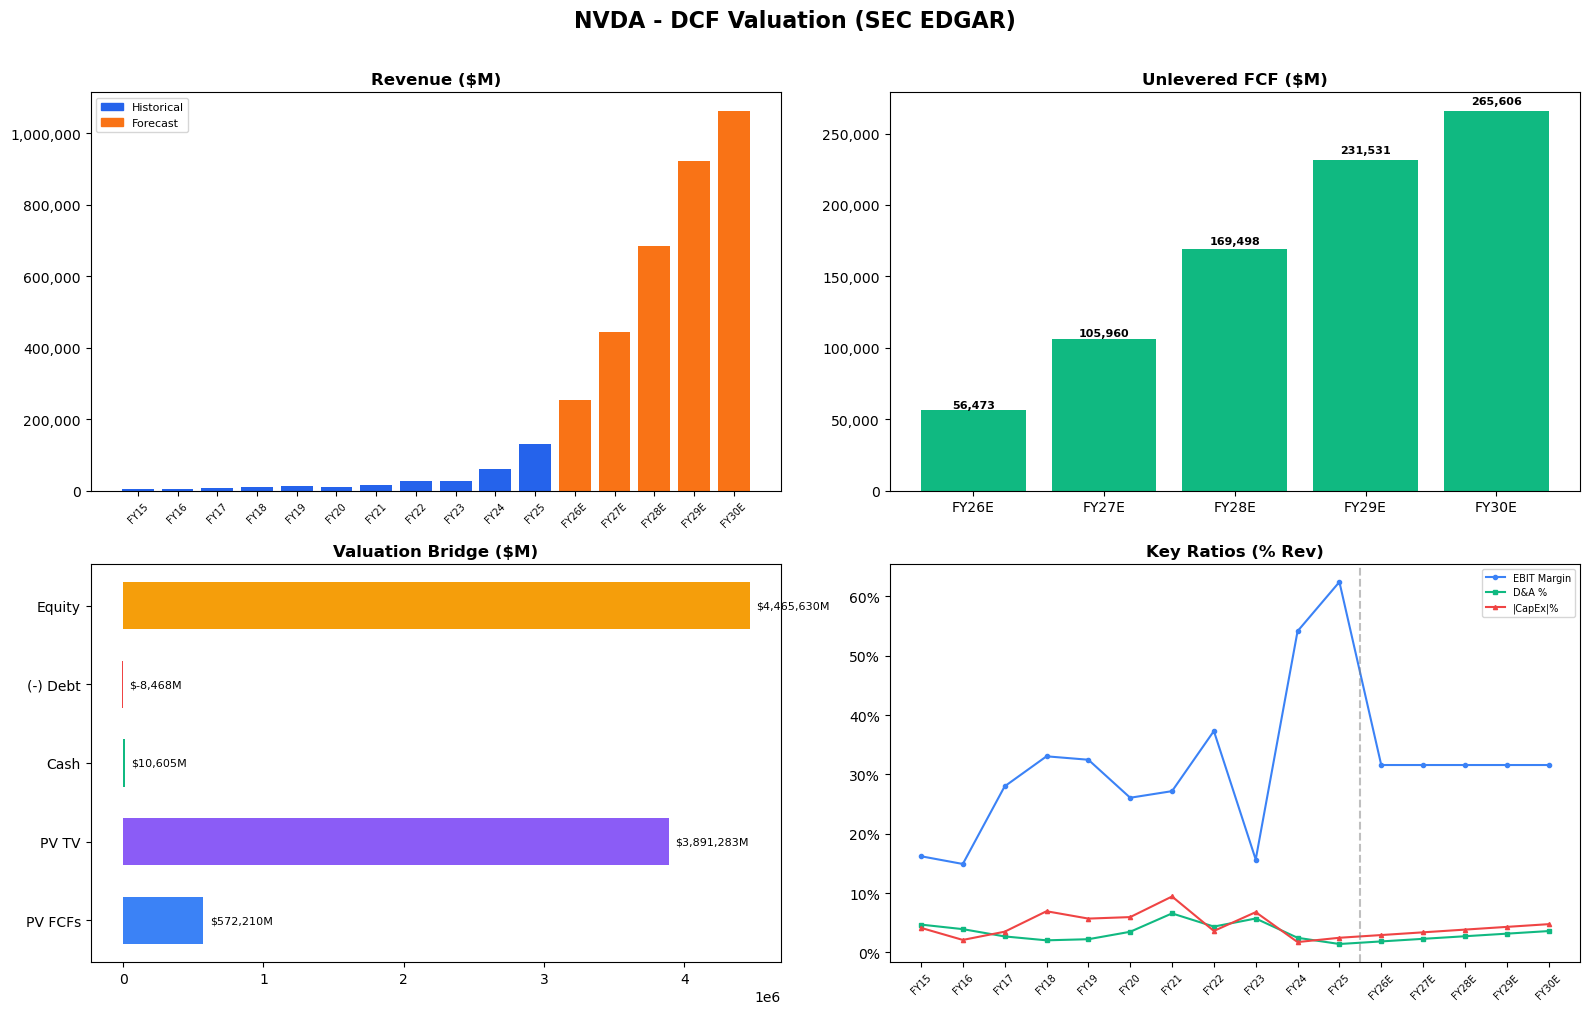

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'{TICKER} - DCF Valuation (SEC EDGAR)', fontsize=16, fontweight='bold', y=1.01)

ax = axes[0,0]
al = list(revenue.index)+flabels
av = list(revenue.values)+f_rev
ax.bar(al, av, color=['#2563eb']*len(revenue)+['#f97316']*FORECAST_YEARS)
ax.set_title('Revenue ($M)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.legend([Patch(color='#2563eb'),Patch(color='#f97316')],['Historical','Forecast'],fontsize=8)

ax = axes[0,1]
bars = ax.bar(flabels, f_ufcf, color='#10b981')
ax.set_title('Unlevered FCF ($M)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for b,v in zip(bars,f_ufcf):
    ax.text(b.get_x()+b.get_width()/2, v*1.02, f'{v:,.0f}', ha='center', fontsize=8, fontweight='bold')

ax = axes[1,0]
bv = [sum(pv_fcfs), pv_tv, latest_cash, -latest_debt, eq_val]
ax.barh(['PV FCFs','PV TV','Cash','(-) Debt','Equity'], bv,
        color=['#3b82f6','#8b5cf6','#10b981','#ef4444','#f59e0b'], height=0.6)
ax.set_title('Valuation Bridge ($M)', fontweight='bold')
for i,v in enumerate(bv):
    ax.text(max(0,v)+max(bv)*0.01, i, f'${v:,.0f}M', va='center', fontsize=8)

ax = axes[1,1]
al2 = list(revenue.index)+flabels
ax.plot(al2, list(ebit_margin)+fc['ebit_margin'], 'o-', label='EBIT Margin', color='#3b82f6', ms=3)
ax.plot(al2, list(da_pct_rev)+fc['da_pct'], 's-', label='D&A %', color='#10b981', ms=3)
ax.plot(al2, list(abs(capex_pct_rev))+[abs(x) for x in fc['capex_pct']], '^-', label='|CapEx|%', color='#ef4444', ms=3)
ax.axvline(len(revenue)-0.5, color='gray', ls='--', alpha=0.5)
ax.set_title('Key Ratios (% Rev)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(fontsize=7); ax.tick_params(axis='x', rotation=45, labelsize=7)
plt.tight_layout(); plt.show()